# Tensor Reconstruction Test
This notebook tests the reconstruction of a PyTorch tensor from pruned saliency maps stored in `TempPruneSaliencyMap`.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os
import sys
import django
import torch

# Setup Django environment
# Adjust the path to point to the directory containing manage.py
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../hiccup_ide")))
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "hiccup_ide.settings")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"
django.setup()

In [16]:
from neural_data.models import WorkGraph, TempPruneSaliencyMap, Work
from neural_data.api.saliency import reconstruct_layer_tensor, _get_cached_mnist_model, _get_cached_mnist_input_tensor
from pt_to_api.utils import show_single_channel_red_green_black as S
from pt_to_api.mnist import get_contribs_for_inp_vectorized, SimpleMNIST

## 1. Configuration
Pick a graph and a layer to test. Ensure you have run `initialize_pruning_session` 
or manually populated `TempPruneSaliencyMap` for this graph.

In [4]:
Work.objects.all().last().name

'default-workflow'

In [5]:
# Example aliases - adjust based on your database content
WORK_ALIAS = "default-workflow"
GRAPH_ALIAS = "default_pruned_graph"
LAYER_NAME = "layers.3" 

graph = WorkGraph.objects.filter(work__name=WORK_ALIAS, alias=GRAPH_ALIAS).first()

if not graph:
    print(f"Graph not found for work '{WORK_ALIAS}' and alias '{GRAPH_ALIAS}'")
    # List available graphs to help selection
    available = WorkGraph.objects.all()[:5]
    if available:
        print("Available graphs:")
        for g in available:
            print(f"  Work: {g.work.name}, Alias: {g.alias}")
else:
    print(f"Found graph: {graph.pk}")

Found graph: 2


## 2. Reconstruct Tensor
This calls the refactored `reconstruct_layer_tensor` function.

In [6]:
if graph:
    tensor = reconstruct_layer_tensor(graph, LAYER_NAME)
    
    if tensor is not None:
        print(f"Successfully reconstructed tensor for layer: {LAYER_NAME}")
        print(f"Tensor Shape: {tensor.shape}")
        print(f"Tensor Device: {tensor.device}")
        
        # Check non-zero elements to see if it's populated
        non_zero = torch.count_nonzero(tensor)
        print(f"Non-zero elements: {non_zero} / {tensor.numel()}")
        
        # Display sample from first channel if exists
        if tensor.shape[1] > 0:
             print("\nSample from Channel 0 (top-left 5x5):")
             print(tensor[0, 0, :5, :5])
    else:
        print(f"No output_channel coordinates found for layer '{LAYER_NAME}' in graph {graph.pk}")
        # List available layers in this graph's scratchpad
        layers = TempPruneSaliencyMap.objects.filter(graph=graph).values_list('layer_name', flat=True).distinct()
        print(f"Available layers in scratchpad: {list(layers)}")

Successfully reconstructed tensor for layer: layers.3
Tensor Shape: torch.Size([1, 16, 7, 7])
Tensor Device: cpu
Non-zero elements: 12 / 784

Sample from Channel 0 (top-left 5x5):
tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])


In [12]:
import matplotlib.pyplot as plt
def _show_layer(tens):
    S([t for t in tens[0]], ncols=4)
    plt.show()

In [7]:
tensor = reconstruct_layer_tensor(graph, "layers.3")

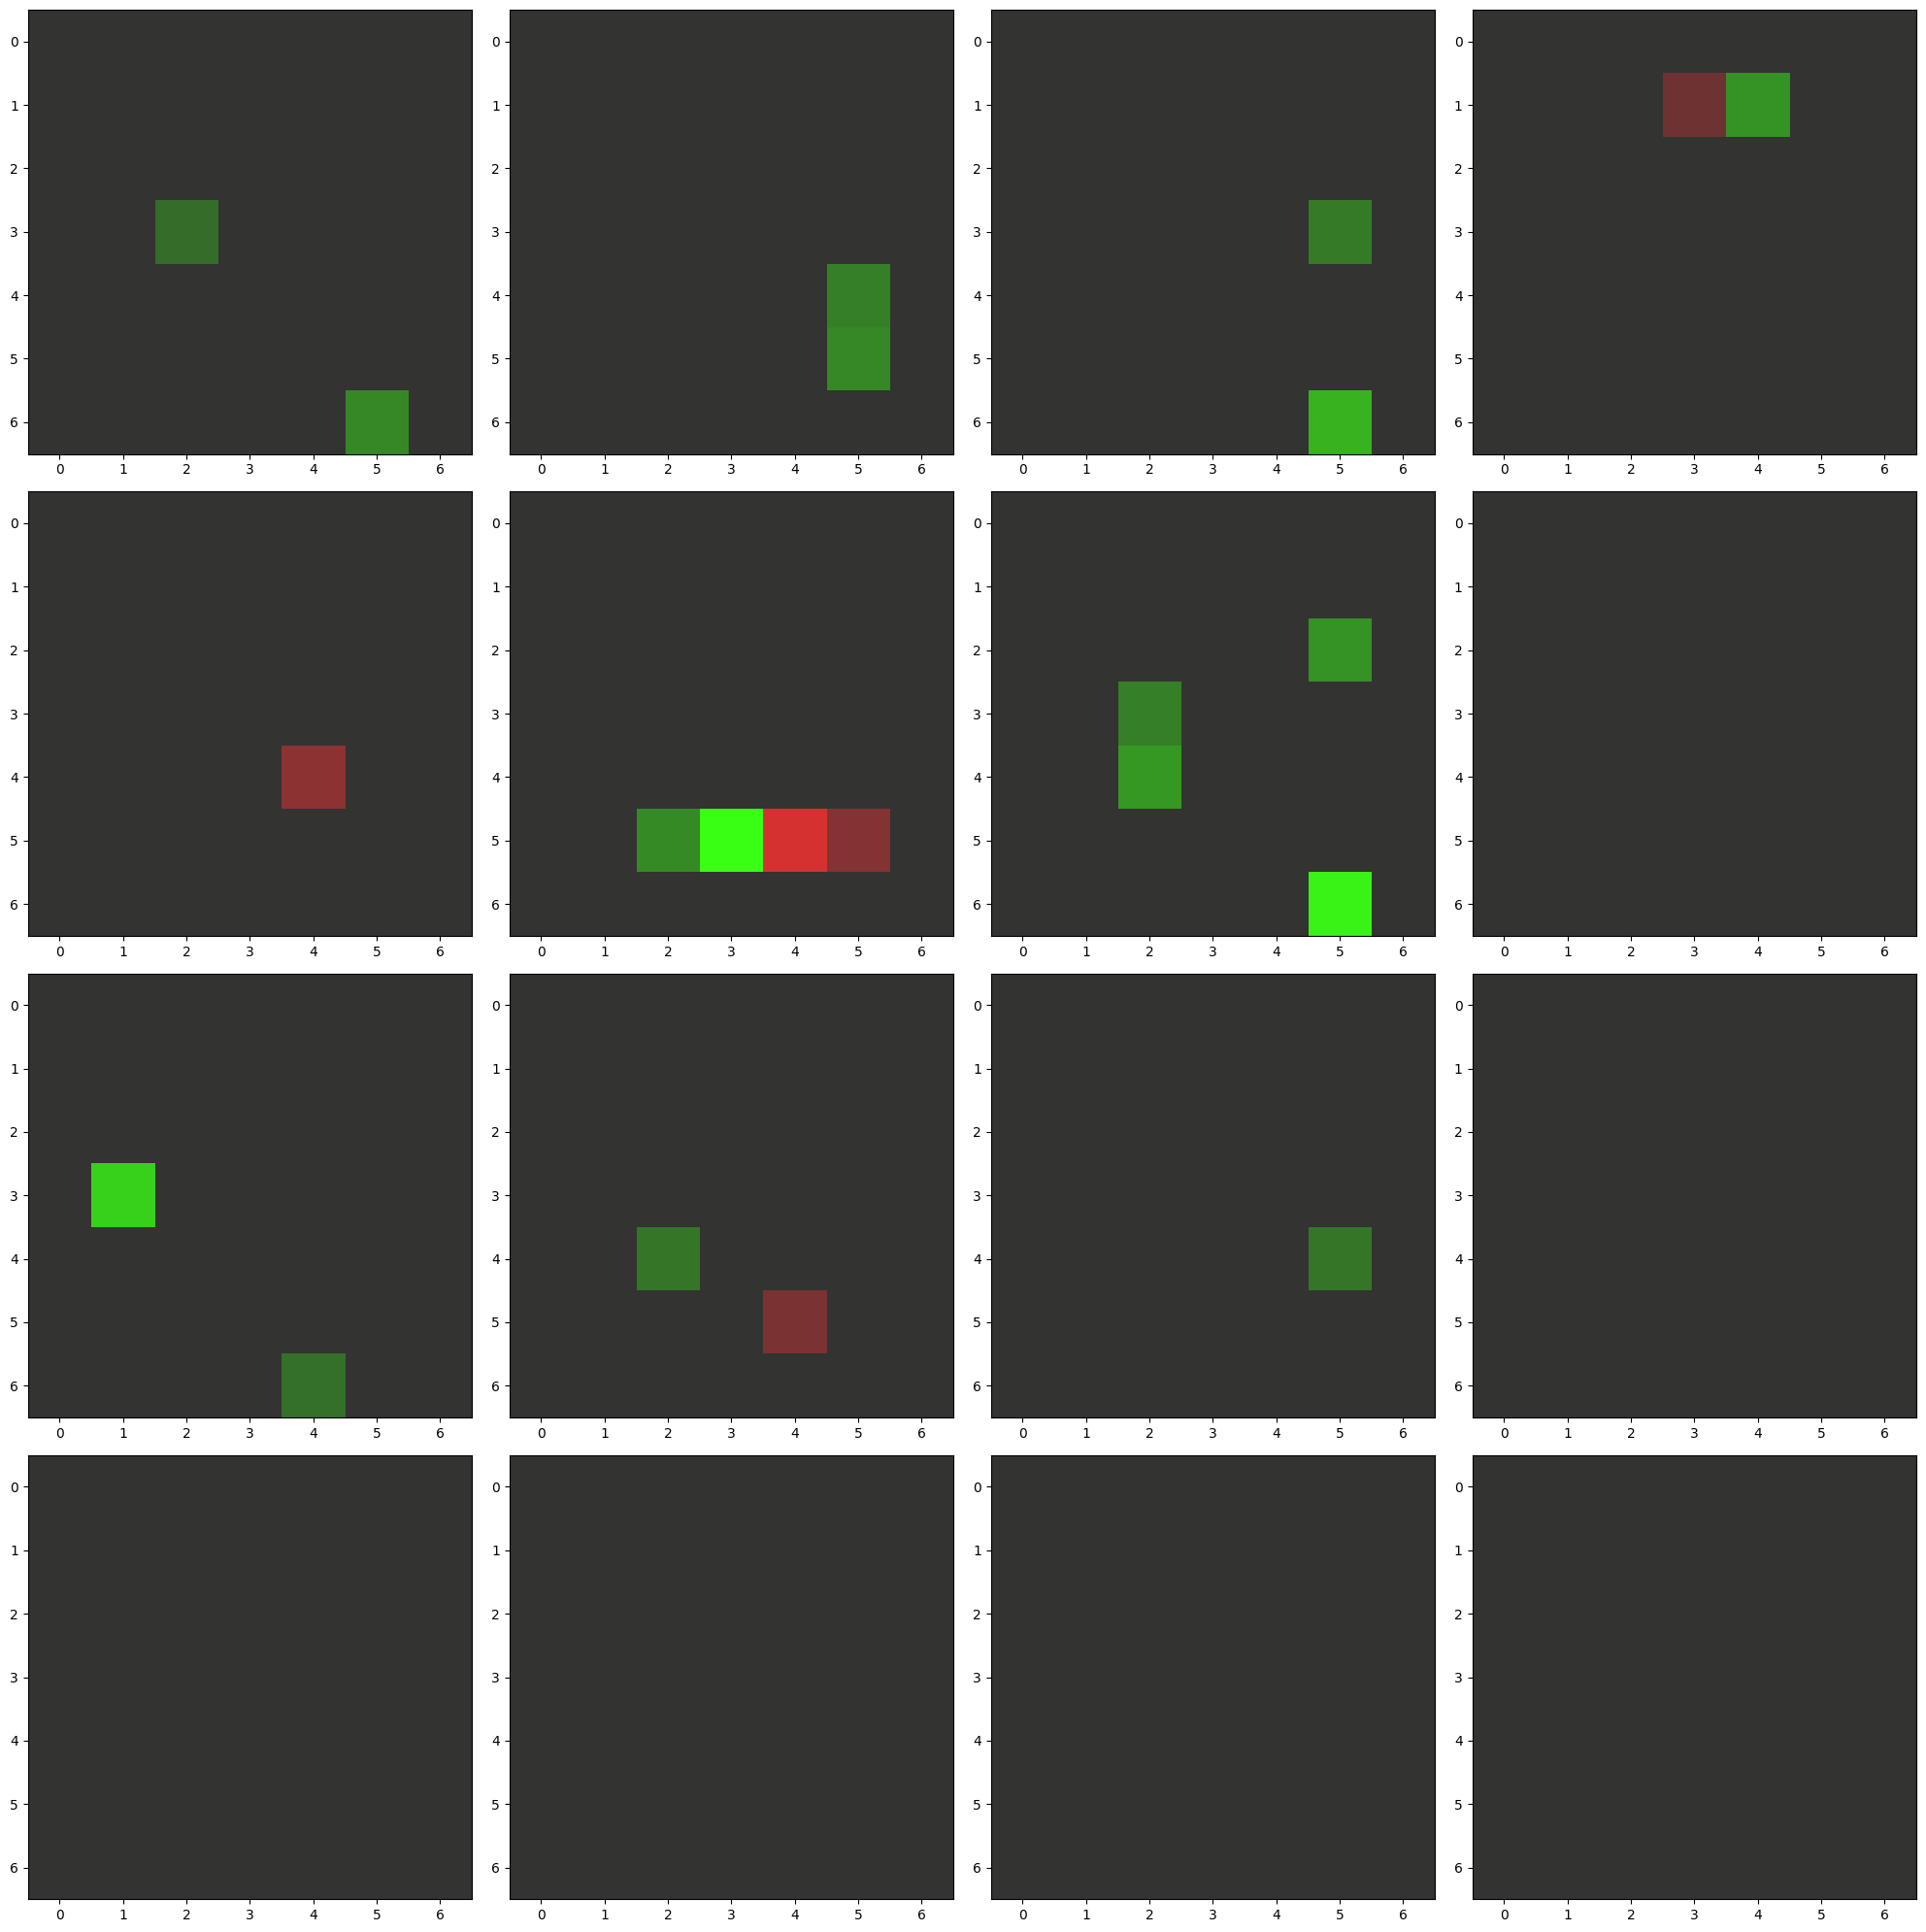

In [13]:
_show_layer(tensor)

In [23]:
contribs, _, _ = get_contribs_for_inp_vectorized(
    _get_cached_mnist_input_tensor(), _get_cached_mnist_model(), tensor, "layers.3", "cpu"
)


backpropping 2


In [24]:
contribs["layers.2"]

tensor([[[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0166,  0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0243,  0.0000]],

         [[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0220,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0243,  0.0000],
          [ 0.0000,  0.

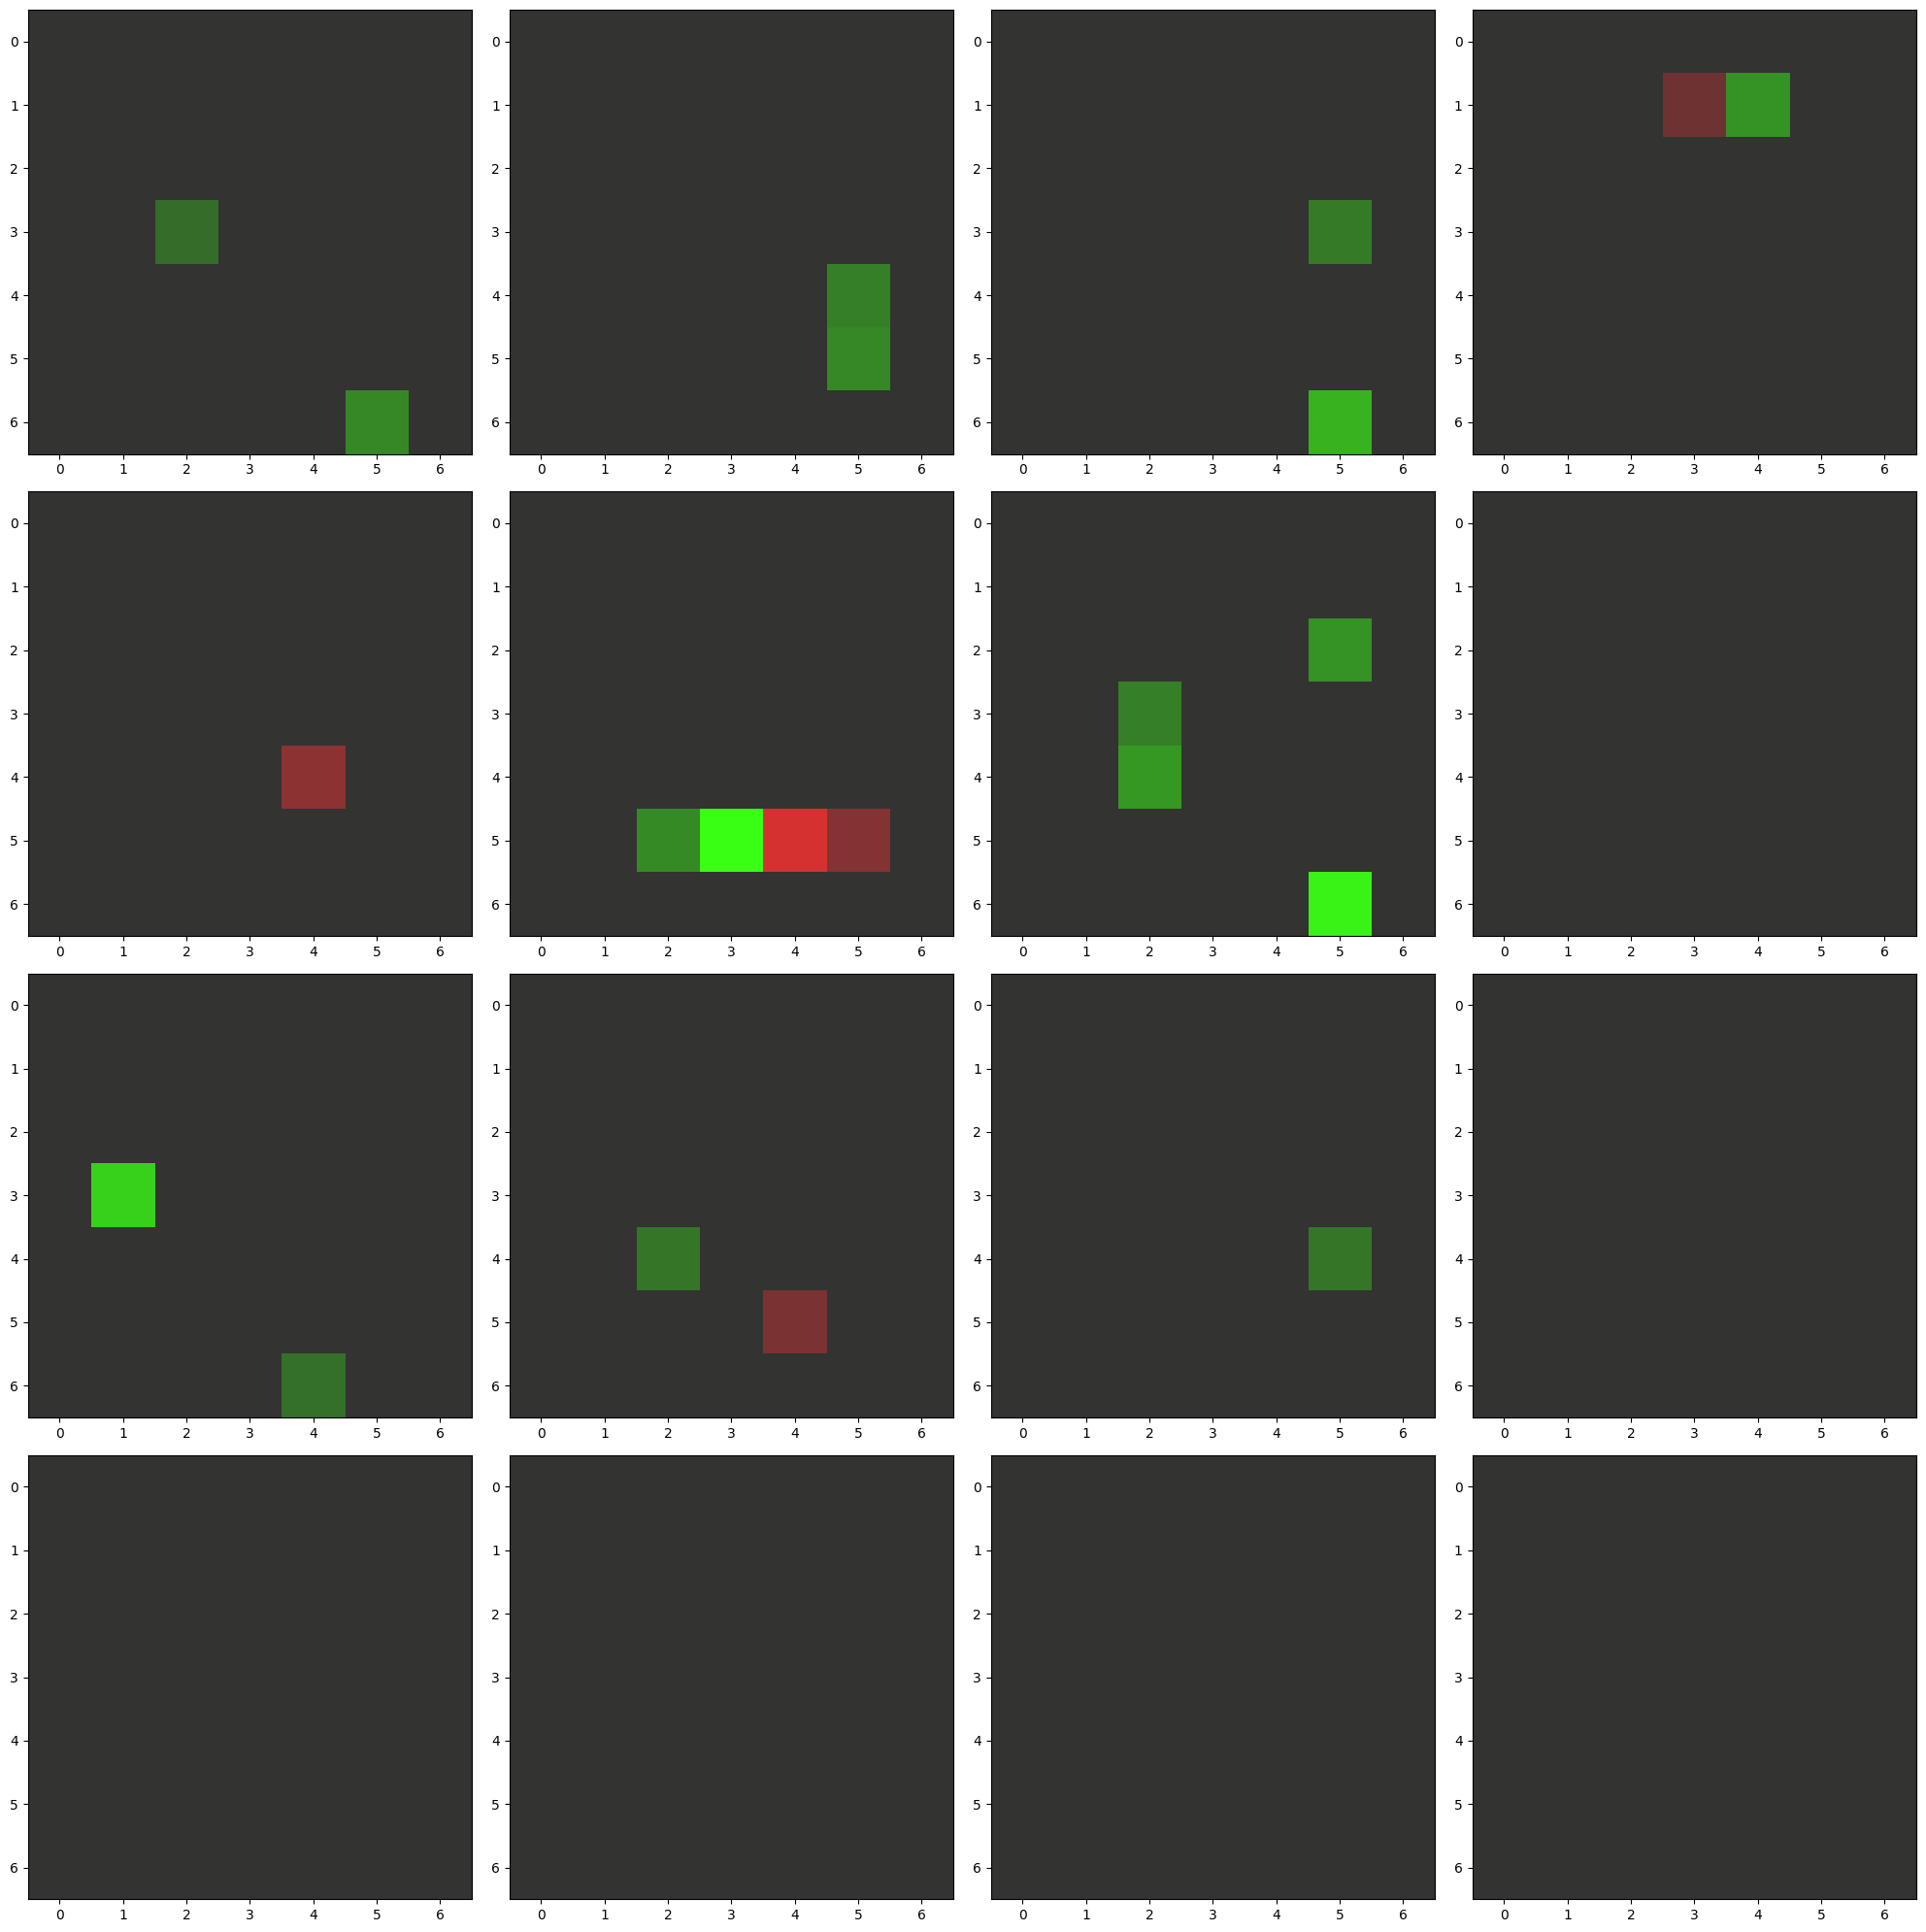

In [26]:
_show_layer(contribs["layers.2"])

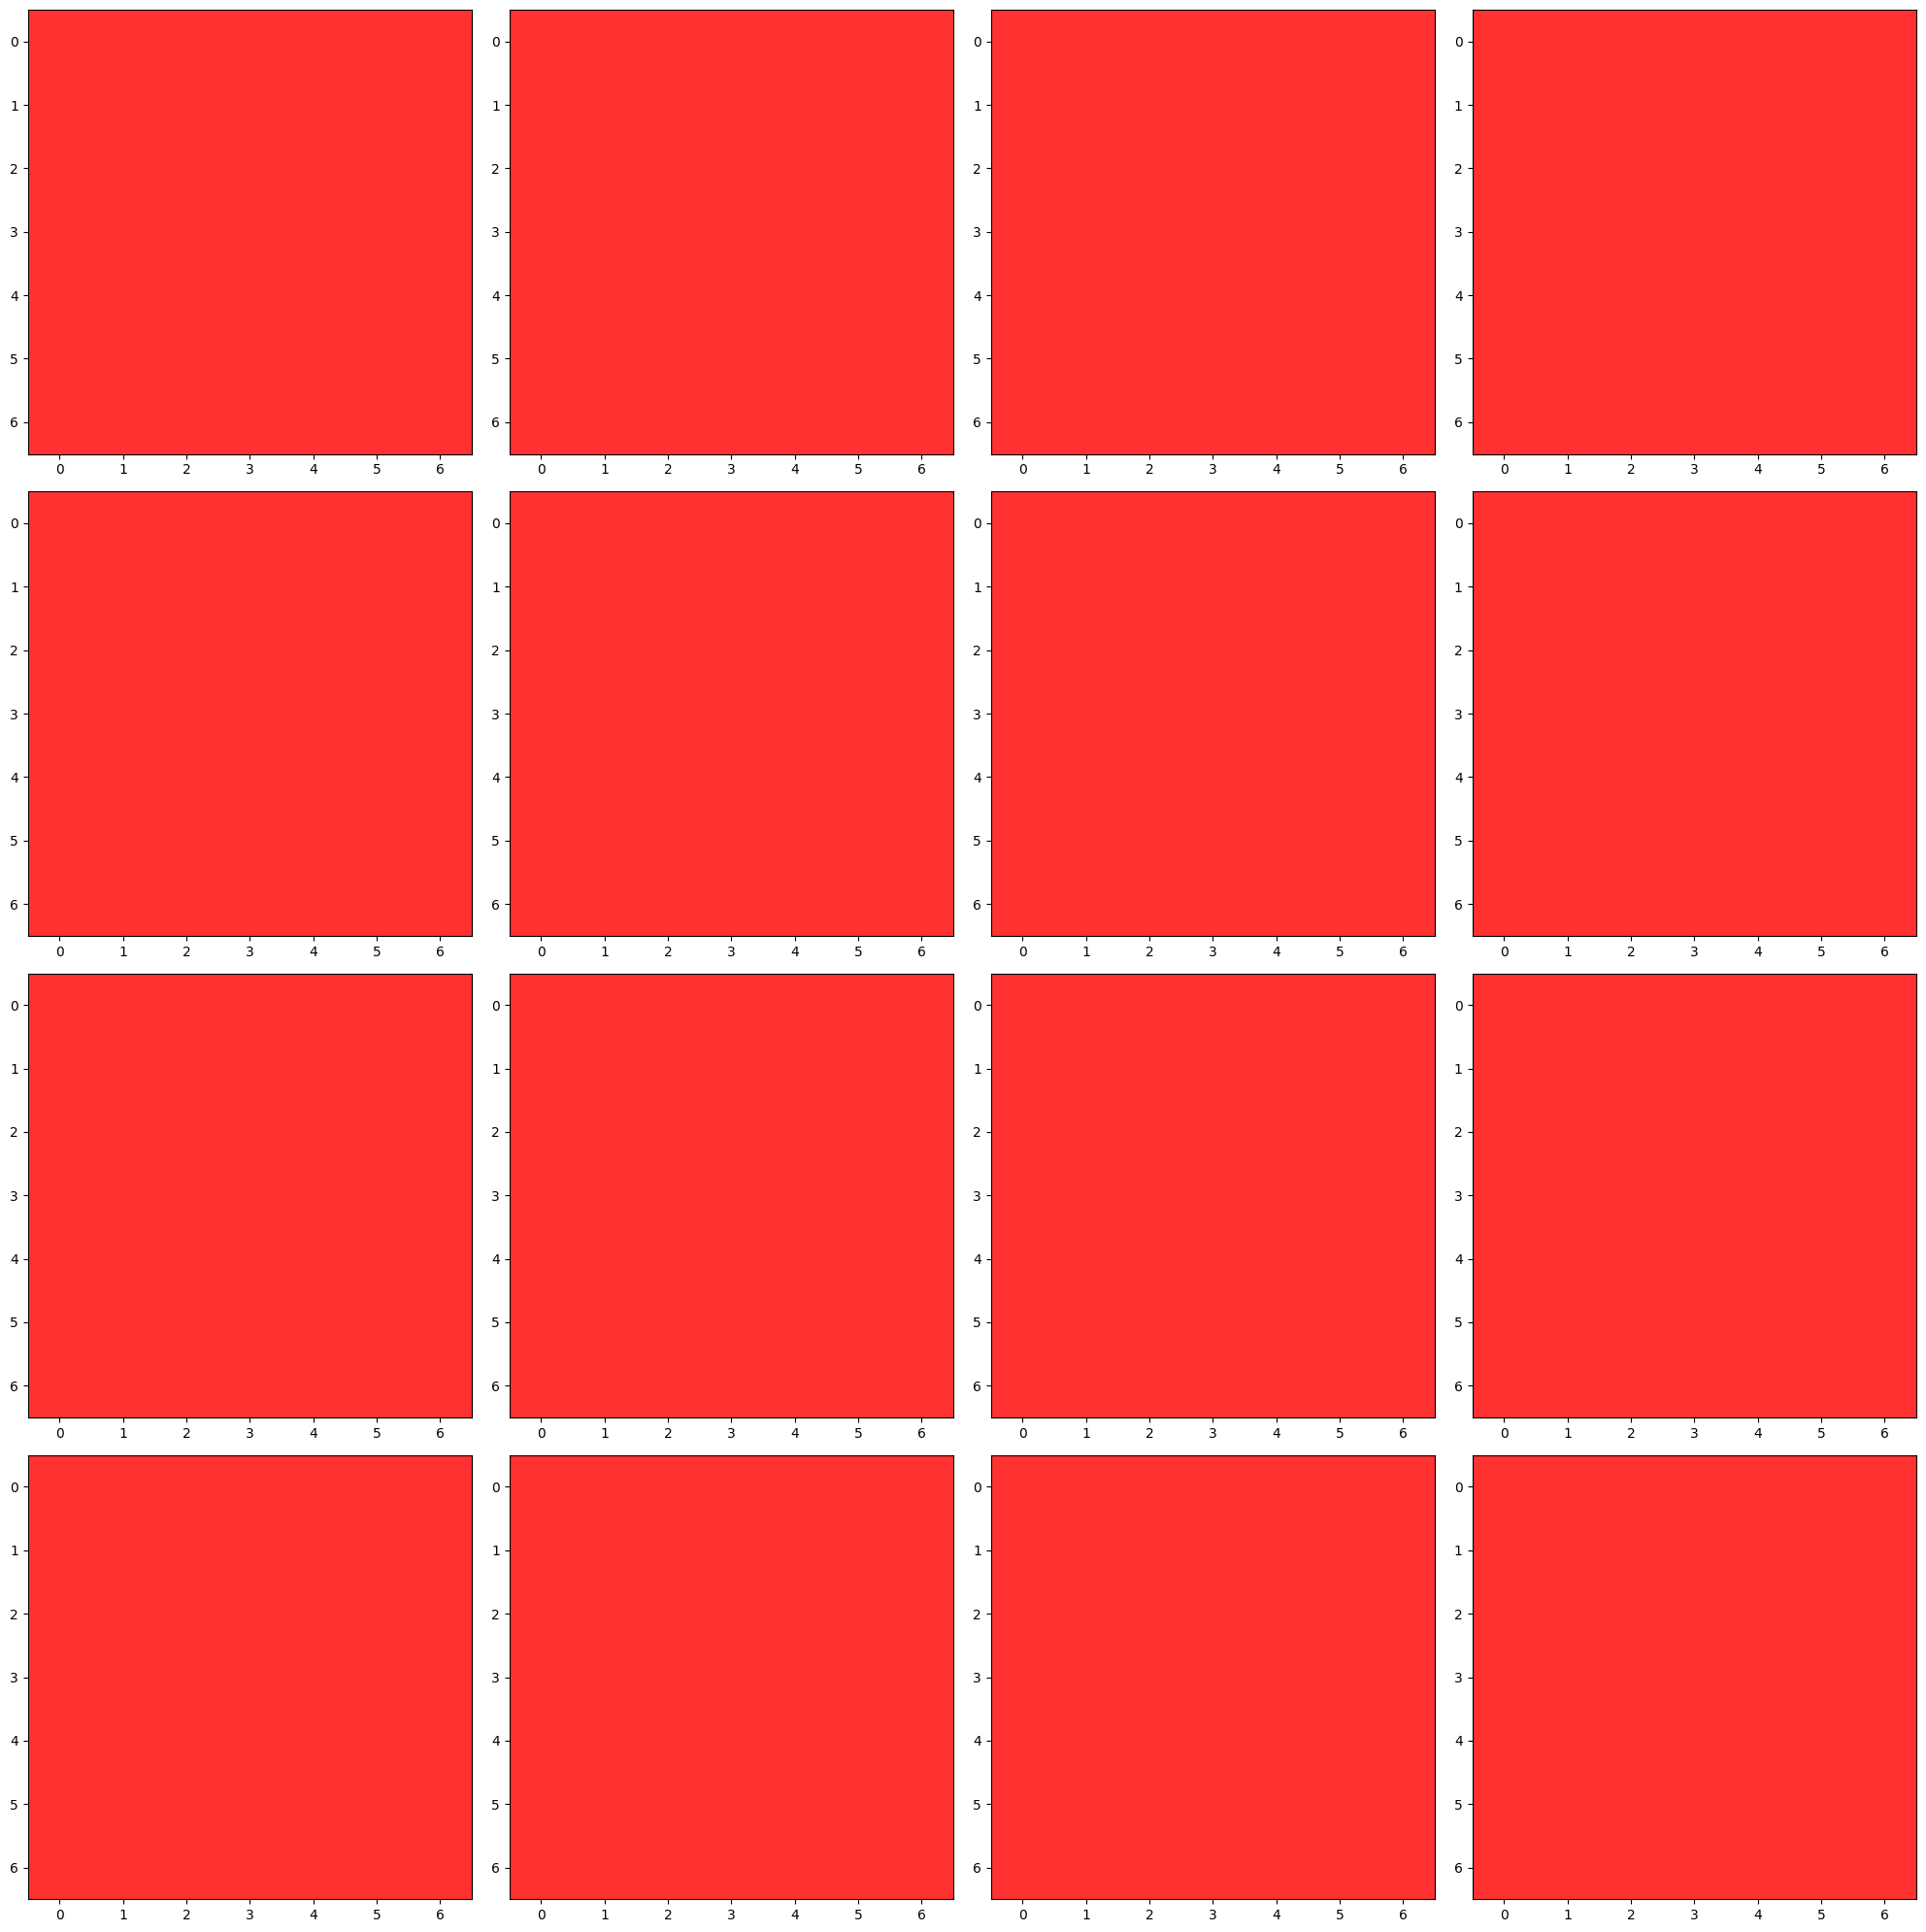

In [25]:
l2_tensor = reconstruct_layer_tensor(graph, "layers.2")
_show_layer(l2_tensor)

In [8]:
from pt_to_api.utils import show_single_channel_red_green_black as S

In [9]:
from pt_to_api.mnist import get_contribs_for_inp_vectorized, SimpleMNIST

MODEL_PATH = (
    "/Users/hariomnarang/Desktop/personal/hiccup-ide/pt-to-api/data/model.pt"
)
INPUT_PATH = "/Users/hariomnarang/Desktop/personal/hiccup-ide/pt-to-api/data/first-input-tens.pt"



model = SimpleMNIST()
model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
model.eval()
batch_inp_tens = torch.load(
    INPUT_PATH, map_location="cpu", weights_only=False
)

In [10]:
model

SimpleMNIST(
  (layers): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=784, out_features=10, bias=True)
  )
)

In [22]:
from pt_to_api.utils import zeros_with_1_at
# original
og_contribs, _, _ = get_contribs_for_inp_vectorized(batch_inp_tens, model, zeros_with_1_at(10, 9), "layers.5", "cpu")
contribs, _, _ = get_contribs_for_inp_vectorized(batch_inp_tens, model, tensor, LAYER_NAME, "cpu")

lsat layer keyyyyyyyyyl layers.5
last layer indexxxxxx 5
lsat layer keyyyyyyyyyl layers.3
last layer indexxxxxx 3


In [ ]:
for k in og_contribs.keys():
    print(og_contribs[k].shape == contribs[k].shape)

True
True
True
True
True
True
True
True
True


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

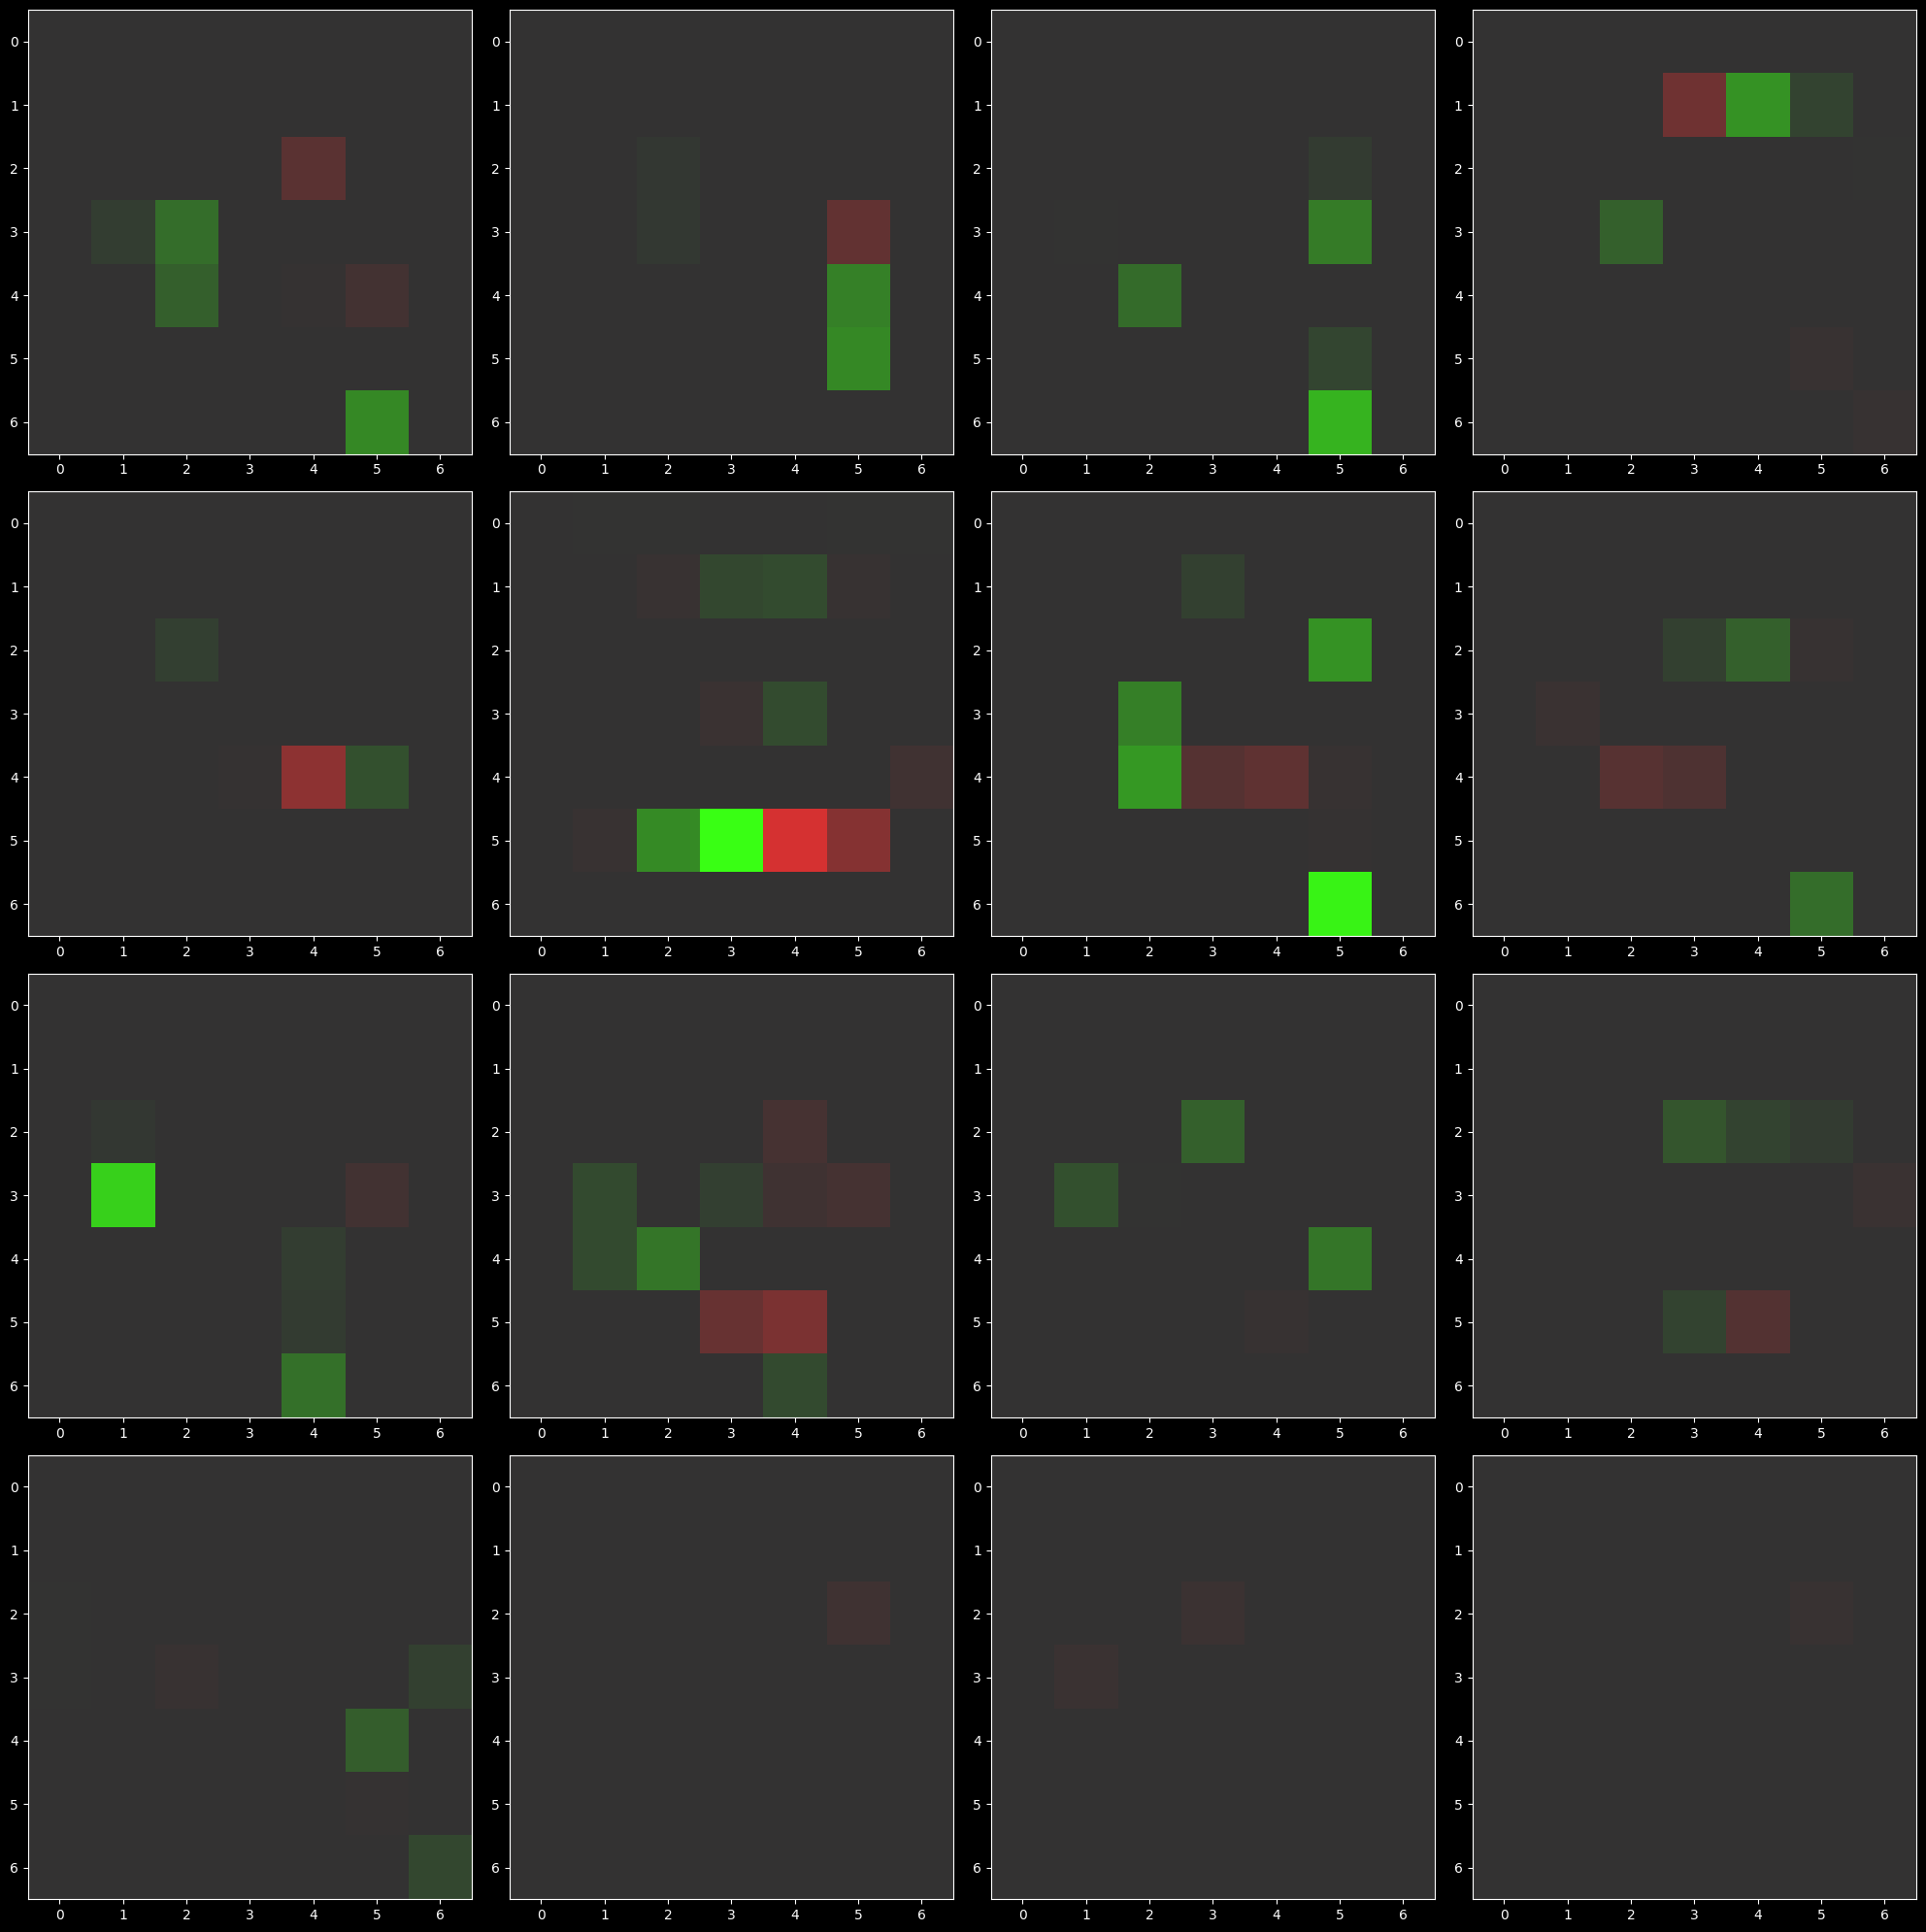

In [21]:
S([t.cpu().detach() for t in og_contribs["layers.3"][0]], ncols=4, viztype="global")

In [22]:
from pt_to_api.contrib_processor import process_contribs_to_coordinates

new_coords_dict = process_contribs_to_coordinates(
    contribs, sample_idx=0
)

TypeError: 'int' object is not subscriptable

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

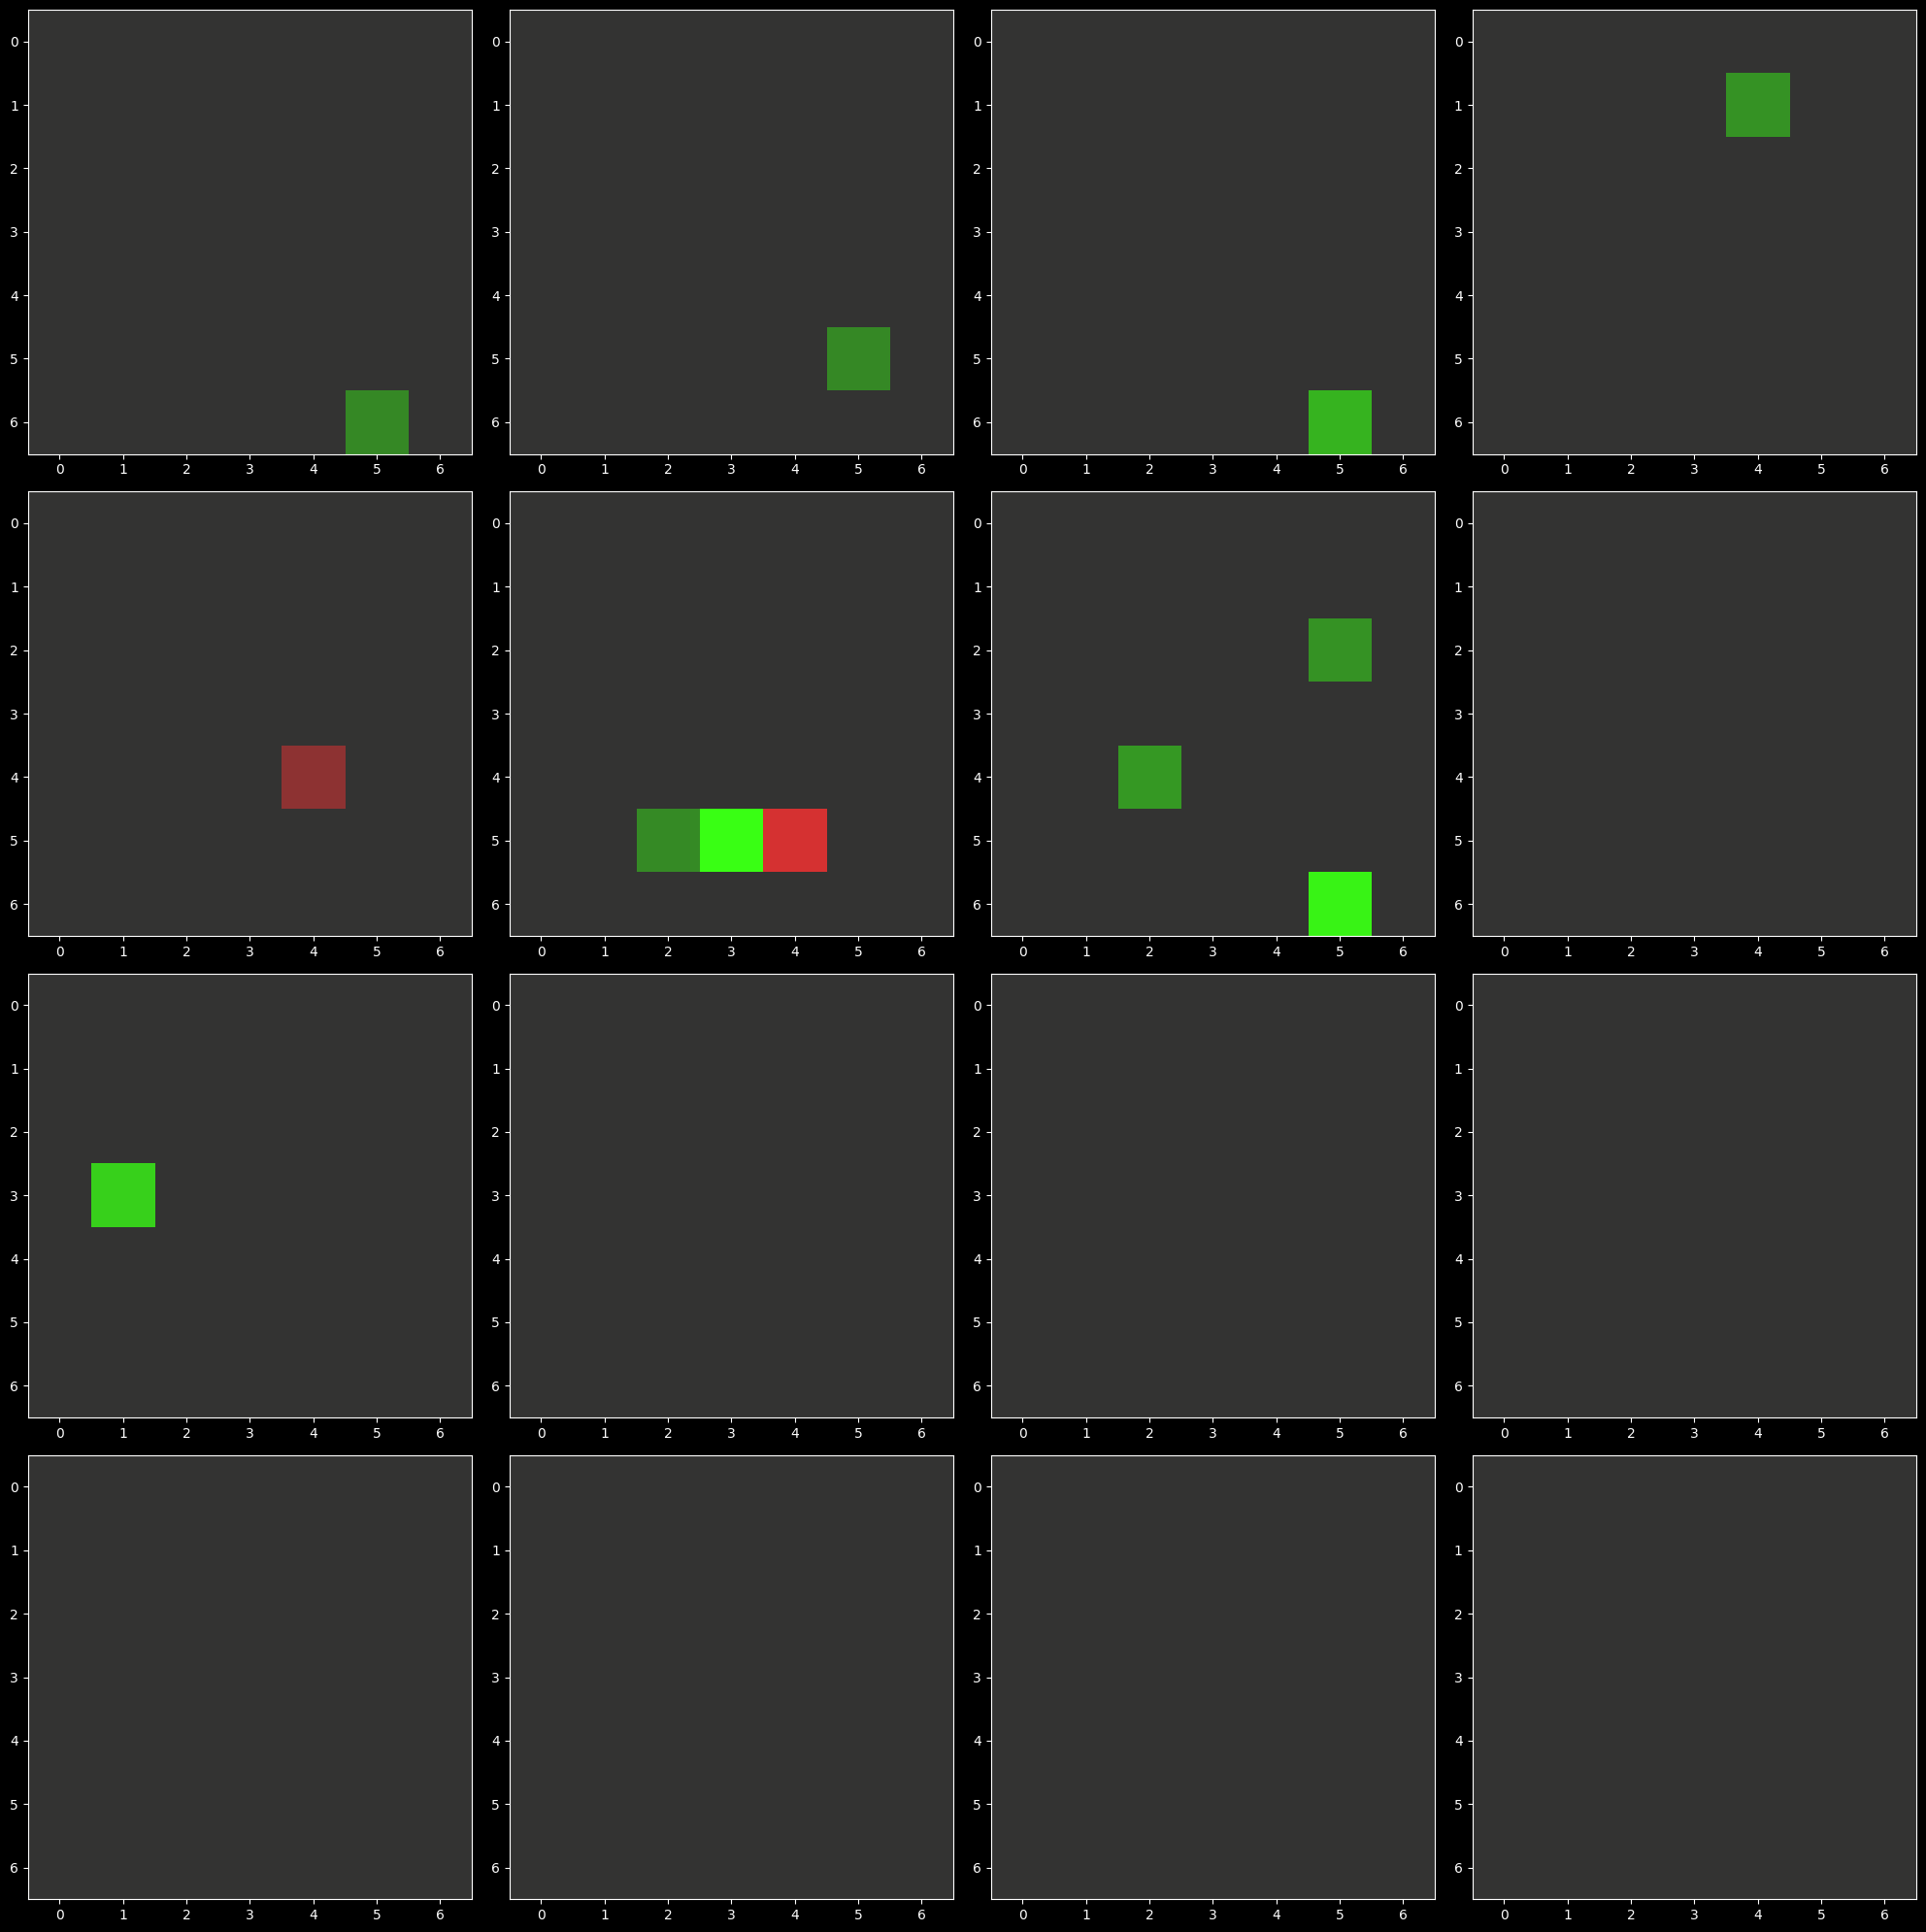

In [11]:
S([t.cpu().detach() for t in tensor[0]], ncols=4, viztype="global")